In [92]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

# 2-1

## (a)

In [93]:
B_0 = 1 # Tesla
B_1 = 0.2e-3 # driving field strength B_x in Tesla

# gyromagnetic ratio (MHz / Tesla for proper units)
GAM_2PI = 42.577

LARMOR = 2 * np.pi * GAM_2PI * B_0
RABI = 2 * np.pi * GAM_2PI * B_1

# defined w.r.t. x axis as driving axis (not arbitrary angle phi)
H = lambda fq_drive : -0.5 * (
    (LARMOR - fq_drive) * qt.sigmaz() - RABI * qt.sigmax()
)

## (b)

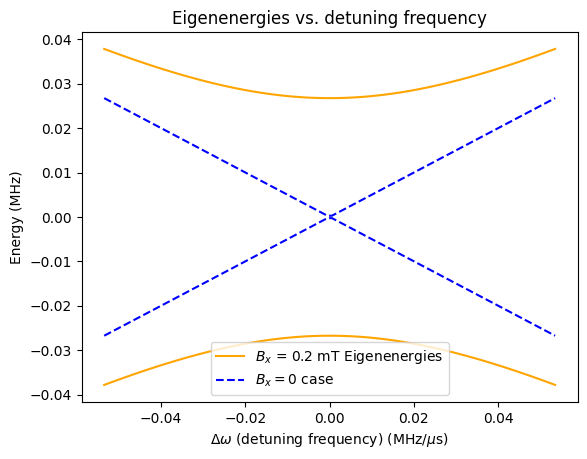

In [94]:
detunings = np.linspace(-RABI, RABI, 100) # LARMOR/2 being abs. max detuning

# Generate B_x = 0 case
H_zero = lambda fq_drive : -0.5 * (
    (LARMOR - fq_drive) * qt.sigmaz()
)

e_energ1 = []
e_energ2 = []
e_energy_zeros = np.empty((len(detunings),2))

for idx, delta in enumerate(detunings):
    # calculate corresponding rabi freq.
    fq_rabi = LARMOR - delta
    evals = H(fq_rabi).eigenenergies()
    e_energ1.append(evals[0])
    e_energ2.append(evals[1])
    nodrive_evals = H_zero(fq_rabi).eigenenergies()
    e_energy_zeros[idx, 0] = nodrive_evals[0]
    e_energy_zeros[idx, 1] = nodrive_evals[1]

fig, ax = plt.subplots()

ax.plot(detunings, e_energ1, color="orange", label="$B_x$ = 0.2 mT Eigenenergies")
ax.plot(detunings, e_energ2, color="orange")
ax.plot(detunings, np.full_like(detunings, e_energy_zeros[:, 0]), color="b", label="$B_x=0$ case", ls='--')
ax.plot(detunings, np.full_like(detunings, e_energy_zeros[:, 1]), color='b', ls="--")
ax.set_ylabel(r"Energy (MHz)")
ax.set_xlabel(r"$\Delta \omega$ (detuning frequency) (MHz/$\mu$s)")
ax.set_title("Eigenenergies vs. detuning frequency")
ax.legend()
plt.show()


## (c)

What are the eigenvectors for positive and negative detuning, and for on-resonance driving.
Compare these to the bare eigenstates without the driving field. This can be calculated
done analytically or numerically. Please discuss the result.


In [95]:
from IPython.display import display, Math
#Detuning
detuning = [-0.35, 0, 0.35]

for delta in detuning:
    fq_rabi = LARMOR - delta
    _, evecs = H(fq_rabi).eigenstates()
    for evec in evecs:
        display(evec)

print("Comparing with bare field:")
for delta in detuning:
    fq_rabi = LARMOR - delta
    _, evecs = H_zero(fq_rabi).eigenstates()
    for evec in evecs:
        display(evec)


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.07577418]
 [-0.997125  ]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.997125  ]
 [-0.07577418]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [ 0.70710678]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.997125  ]
 [ 0.07577418]]

...

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-1.]
 [-0.]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-1.]
 [-0.]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.]
 [ 1.]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-1.]
 [ 0.]]

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]

These expiraments essentially demonstrate the axis about which we rotate under different circumstances. We see that even with a small degree of detuning relative to the Larmor frequency, the difference in strength of both magnetic fields is so great that the Z axis magnetic field easily overpowers the X axis magnetic field and we see *essentially* a Z rotation, or rotation about the Z-axis (the amount of detuning reflects the speed of this rotation). It's slightly off from the exact Z-axis, which reflects the presence of a small contribution of the X-axis magnetic field.

However, when we match the driving frequency of the x axis to that of the Larmor procession of the nucleus spins, suddenly there is no relative motion between the reference frame and the spin around the z-axis (in the rotating frame). This just leaves the x influence, which is reflected in the eigenvector showing halfway between the x and z planes (a standard x rotation).

## (d)

For resonant driving ($ω$ = $ω_0$): Start with the spin in |0⟩ and let it evolve with H. Plot the
expectation values of σx,y,z . Don’t forget labels and units on your axes.

In [96]:
H_resonant = H(LARMOR)

ket_init = qt.basis(2, 0)

T = np.linspace(0, 200, 100)

evolution = qt.sesolve(H_resonant, ket_init, T, e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()])

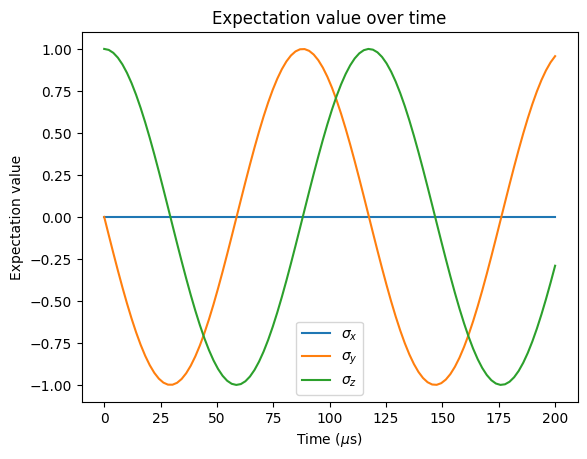

In [97]:
fig, ax = plt.subplots()

labels = [r"$\sigma_x$", r"$\sigma_y$", r"$\sigma_z$"]
for label, op in zip(labels, evolution.expect):
    ax.plot(T, op, label=label)

ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("Expectation value")
ax.set_title("Expectation value over time")
ax.legend();


## (e)

For resonant driving (ω = ω0): What is the duration for a π−pulse and for a π/2−pulse?

In [98]:
sigma_y = np.asarray(evolution.expect[1])
sigma_z = np.asarray(evolution.expect[2])
T_arr = np.asarray(T)

# Use the expected resonant Rabi solution to pick the pulse times
t_pi2_expected = np.pi / (2 * RABI)
t_pi_expected = np.pi / RABI

# Choose the closest sampled times from the evolved data
i_pi2 = np.argmin(np.abs(T_arr - t_pi2_expected))
i_pi = np.argmin(np.abs(T_arr - t_pi_expected))

t_pi2 = T_arr[i_pi2]
t_pi = T_arr[i_pi]

print(f"Time for pi/2 pulse: {t_pi2:.4g} us")
print(f"Time for pi pulse: {t_pi:.4g} us")
print(f"Expected pi/2 pulse: {t_pi2_expected:.4g} us")
print(f"Expected pi pulse: {t_pi_expected:.4g} us")


Time for pi/2 pulse: 30.3 us
Time for pi pulse: 58.59 us
Expected pi/2 pulse: 29.36 us
Expected pi pulse: 58.72 us


Thus we:
1. Demonstrated the analytic solution for the times of each pulse.
2. Demonstrated that our model follows this (down to error of the relativly coarse timestep)

## (f)

For resonant driving: Use the Hamiltonian to create the following Ramsey pulse sequence:
π/2 − τ − π/2 with the interval time τ = 25 μs. Plot the evolution of the expectation values.

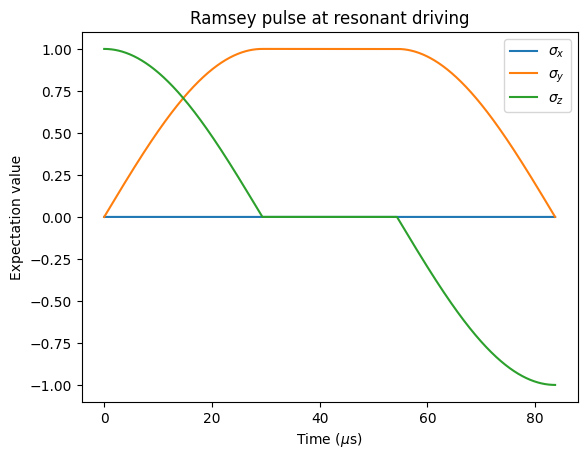

In [99]:
t_pi2 = np.pi / (2 * RABI)

delta = 0

H_drive = -0.5 * (delta * qt.sigmaz() + RABI * qt.sigmax()) # first term = zero because perfectly resonant
H_off =  -0.5 * (delta * qt.sigmaz())

# assume starting ket 0
ket_init = qt.basis(2, 0)

TAU = 25 # us
T = np.linspace(0, (2*t_pi2 + TAU), 1500)

pulse_args = {
    't_pi2': t_pi2, 
    'TAU': TAU
} # Using cython bc it's faster and I am familiar with C

H = [
    [H_drive, 't < t_pi2'],
    [H_off,   '(t >= t_pi2) * (t < (t_pi2 + TAU))'],
    [H_drive, 't >= (t_pi2 + TAU)']
]

result = qt.sesolve(H,
                    ket_init,
                    T,
                    args=pulse_args,
                    e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()])

fig, ax = plt.subplots()

ax.plot(T, result.expect[0], label='$\sigma_x$');
ax.plot(T, result.expect[1], label='$\sigma_y$');
ax.plot(T, result.expect[2], label='$\sigma_z$');
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("Expectation value")
ax.set_title("Ramsey pulse at resonant driving")

ax.legend();

## (g)

Now consider a random magnetic field generated by a subway train at a distance of 100 m
on the experiment. To model the random phase shifts that such a random magnetic field
will cause, assume a Gaussian current distribution centered around 0 A with a width
(sigma) of 1000 A, which produces a magnetic field in the ˆz direction, effectively from an
infinitely long straight wire perpendicular to ˆz, in the plane of the experiment at a distance
of 100 m. For a single pulse sequence, this field will be have a fixed current, but will
fluctuate from experiment to experiment. Perform 50 Ramsey experiments with 50 random
values from the current distribution. Plot the average spin evolution.

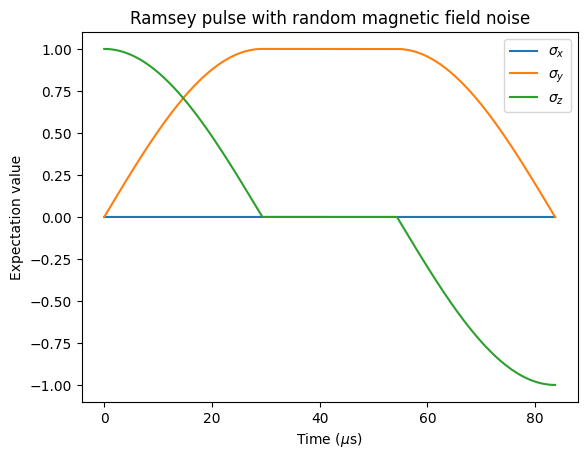

In [100]:
# Sample a gaussian distribution
from numpy.random import default_rng

N = 50

TAU = 25

rng = default_rng()

train_field_strengths = rng.normal(scale=1000, size=N)


# Redefine as fxn of z field strength, driving at supposedly correct resonance
H_drive = lambda z: -0.5 * ((z - LARMOR) * qt.sigmaz() + RABI * qt.sigmax()) # z is variable
H_off =  lambda z: -0.5 * ((z - LARMOR) * qt.sigmaz())

def train_sim(train_field_strengths, TAU):
    T = np.linspace(0, (2*t_pi2 + TAU), 1500)
    avg_expectation = np.zeros((3, len(T)))
    for idx, strength in enumerate(train_field_strengths):
        # calculate combined z field strength
        z_tot = B_0 + 2e-9*strength # convert A -> T @ 100m
        z_larmor = 2 * np.pi * z_tot * GAM_2PI # calculate new larmor freq

        pulse_args = {
            't_pi2': t_pi2, 
            'TAU': TAU
        }

        pulse_options = {
            'max_step': 10.0,
        }

        H = [
            [H_drive(z_larmor), 't < t_pi2'],
            [H_off(z_larmor),   '(t >= t_pi2) * (t < (t_pi2 + TAU))'],
            [H_drive(z_larmor), 't >= (t_pi2 + TAU)']
        ]

        # Calculate expectation
        result = qt.sesolve(H, ket_init, T, e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()], args=pulse_args, options=pulse_options)

        # Recalculate average
        result_time_evolve = np.array(result.expect)

        new_avg = avg_expectation + (result_time_evolve - avg_expectation) / (idx + 1)
        avg_expectation = new_avg
        new_avg = np.zeros_like(avg_expectation)
    return avg_expectation

avg_expectation = train_sim(train_field_strengths, TAU)

fig, ax = plt.subplots()

ax.plot(T, avg_expectation[0], label='$\sigma_x$');
ax.plot(T, avg_expectation[1], label='$\sigma_y$');
ax.plot(T, avg_expectation[2], label='$\sigma_z$');
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("Expectation value")
ax.set_title("Ramsey pulse with random magnetic field noise")
ax.legend();

## (h)

Now pick a few different evolution times τi and study the magnitude of the expectation
values at the end of the Ramsey sequence (still with random B-fields from the subway and
taking 50 measurements at each time step). Discuss the result.

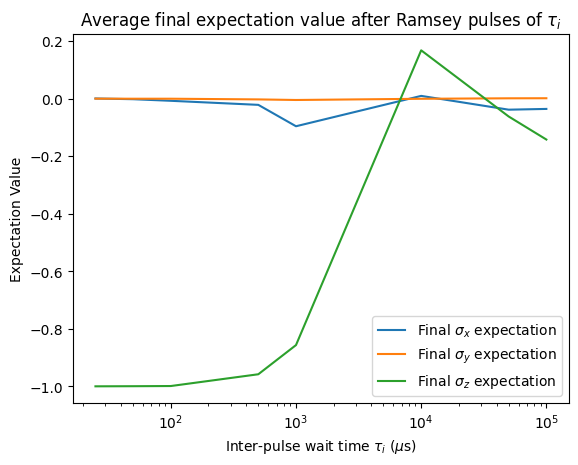

In [101]:
tau_i = [
    25, 50, 100, 500, 1000, 10_000, 50_000, 100_000
]

results = np.zeros((3, len(tau_i)))

for idx, TAU in enumerate(tau_i):
    new_noise = rng.normal(scale=1000, size=N)
    avg_result = train_sim(new_noise, TAU)[:, -1]
    results[:, idx] = avg_result

fig, ax = plt.subplots()

ax.semilogx(tau_i, results[0, :], label=r'Final $\sigma_x$ expectation')
ax.semilogx(tau_i, results[1, :], label=r'Final $\sigma_y$ expectation')
ax.semilogx(tau_i, results[2, :], label=r'Final $\sigma_z$ expectation')

ax.set_title(r"Average final expectation value after Ramsey pulses of $\tau_i$")
ax.set_ylabel("Expectation Value")
ax.set_xlabel(r"Inter-pulse wait time $\tau_i$ ($\mu$s)")
ax.legend();

We see here that after waiting increasingly large amounts of time, the initially very clear expectation values start to decohere and return back to zero. This is not a result of any thermal decoherance, as this was not implemented, but rather the fact that over long time periods, the the phases that are mapped to the x-y plane on the Bloch sphere experience different rates of procession due to the random affect of the train's magnetic field. Then when the x rotation is applied again, the phase will have spread out and will map to a non-deterministic z-level on the bloch sphere. Importantly, since the randomization is gaussian, there will be an approximately even number of spins that get mapped to the top hemisphere and the bottom hemisphere and in equal proportions, so over time as the dephasing becomes more intense, the expectation values at the end of the transformation start to approach zero.

I believe that the expectation value of the sigma y gate is not affected because when we rotate the phases by the final x axis rotation, we essentially map all of the dephased angles to somewhere on the x-z plane, which is always perpendicular to y--measuring the expectation value will return a perfect zero, while the other values will always be affected by some randomness but will approach zero for high enough numbers of particles for a long enough time.

## (i)

Perform a spin echo experiment π/2 − τ − π − τ − π/2 with the randomly fluctuating field
from above (50 measurements). What is the behavior of the final expectation values as a
function of τ ? Discuss the result.

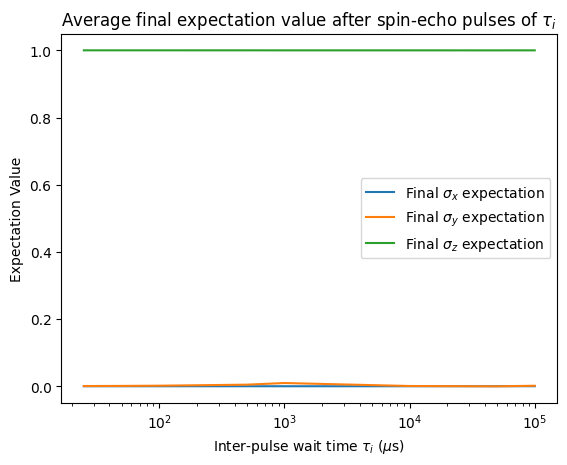

In [102]:
def spin_echo(train_field_strengths, TAU):
    # Calculate T so that we don't run into 
    T = np.linspace(0, (4*t_pi2 + 2*TAU), 5000)
    avg_expectation = np.zeros((3, len(T)))
    for idx, strength in enumerate(train_field_strengths):
        # calculate combined z field strength
        z_tot = B_0 + 2e-9*strength # convert A -> T @ 100m
        z_larmor = 2 * np.pi * z_tot * GAM_2PI # calculate new larmor freq

        pulse_args = {
            't_pi2': t_pi2, 
            'TAU': TAU
        }
        pulse_options = {
            'max_step': 10.0,
        }

        H = [
            [H_drive(z_larmor), 't < t_pi2'],
            [H_off(z_larmor),   '(t >= t_pi2) * (t < (t_pi2 + TAU))'],
            [H_drive(z_larmor), '(t >= (t_pi2 + TAU)) * (t < (3*t_pi2 + TAU))'], # drive for a pi rotation
            [H_off(z_larmor),   '(t >= (3*t_pi2 + TAU)) * (t < (3*t_pi2 + 2*TAU))'],
            [H_drive(z_larmor), 't >= (3*t_pi2 + 2*TAU)']
        ]

        # Calculate expectation
        result = qt.sesolve(H, ket_init, T, e_ops=[qt.sigmax(), qt.sigmay(), qt.sigmaz()], args=pulse_args, options=pulse_options)

        # Recalculate average
        result_time_evolve = np.array(result.expect)

        new_avg = avg_expectation + (result_time_evolve - avg_expectation) / (idx + 1)
        avg_expectation = new_avg
        new_avg = np.zeros_like(avg_expectation)
    return avg_expectation

results = np.zeros((3, len(tau_i)))

for idx, TAU in enumerate(tau_i):
    new_noise = rng.normal(scale=1000, size=N)
    avg_result = spin_echo(new_noise, TAU)[:, -1]
    results[:, idx] = avg_result

fig, ax = plt.subplots()

ax.semilogx(tau_i, results[0, :], label=r'Final $\sigma_x$ expectation')
ax.semilogx(tau_i, results[1, :], label=r'Final $\sigma_y$ expectation')
ax.semilogx(tau_i, results[2, :], label=r'Final $\sigma_z$ expectation')

ax.set_title(r"Average final expectation value after spin-echo pulses of $\tau_i$")
ax.set_ylabel("Expectation Value")
ax.set_xlabel(r"Inter-pulse wait time $\tau_i$ ($\mu$s)")
ax.legend();

Since our noise is not time-dependent, if we do a complete rotation about the x axis, the spin will "switch directions" on the x-y plane while traveling and start moving back towards it's initial value! So if we wait the same amount of time, we will see that all of the spins reconverge to their original values. When we then use another half x rotation, all the spins are sitting perfectly on the y axis again (but on the +y side? Definitely the opposite side), so they will all be re-mapped back up to their starting values!

# Problem 2-2 [10 points]
Generating entanglement. Consider a chloroform molecule (CHCl3)
from Chuang et al., Nature 393, 143 (1998). This problem may be done either by hand or
implemented in QuTiP, as you prefer.

## (a)
Formulate the Hamiltonian in an appropriate rotating frame for 1H and 13C with values
from the paper (including the exchange coupling).

NOTE: IGNORE THE FIRST BLOCK OF CODE: it was a first try and I realized that if you make some
simplifications that I think I could defend, the system gets a lot easier to control... Left it in there
if you're looking for that implementation

In [103]:
# NOTE: I made the code below but I'm not sure I like it... including it just in case
# you prefer it more for some reason

def nmr_two_qubit(drive, coupled=True):
    # Constants from article
    H_FREQ = 500 # MHz
    C_FREQ = 125 # MHz
    J_COUP = 2.15e-3 # MHz
    I2 = qt.qeye(2) # for simplicity
    X = qt.sigmax()

    # Define H as qubit 0
    # and C as qubit 1
    hy = -np.pi * (H_FREQ - drive) * qt.tensor(qt.sigmaz(), I2) # optional detuning in Hz
    ca = -np.pi * (C_FREQ - drive) * qt.tensor(I2, qt.sigmaz()) # optional detuning in Hz

    Hx_H = -np.pi * drive_amp * qt.tensor(X, I2)
    Hx_C = -np.pi * drive_amp * qt.tensor(I2, X)

    if coupled:
        coupling = np.pi * J_COUP * qt.tensor(qt.sigmaz(), qt.sigmaz()) / 2
    else:
        coupling = 0

    H = hy + ca + coupling
    return H


H = nmr_two_qubit(drive=500, coupled=True)
H

NameError: name 'drive_amp' is not defined

In [ ]:
#NOTE: REAL CODE:

# Mathematically equivalent if we ignore the slight tipping that occurs when we "address" a
# specific qubit, up to scaling of the rabi frequency, which is proportional to the driving
# magnetic field strength

def get_H(rabi_x_H=0, rabi_y_H=0, rabi_x_C=0, rabi_y_C=0, coupled=True):
    J_COUP = 2.15e-3 # MHz
    I2 = qt.qeye(2)
    Z, X, Y = qt.sigmaz(), qt.sigmax(), qt.sigmay()

    H = 0 * qt.tensor(I2, I2) # Init empty 4x4 matrix

    # Add control drives
    if rabi_x_H: H += -np.pi * rabi_x_H * qt.tensor(X, I2)
    if rabi_y_H: H += -np.pi * rabi_y_H * qt.tensor(Y, I2)
    if rabi_x_C: H += -np.pi * rabi_x_C * qt.tensor(I2, X)
    if rabi_y_C: H += -np.pi * rabi_y_C * qt.tensor(I2, Y)

    # Add J-coupling
    if coupled:  
        H += np.pi * (J_COUP / 2) * qt.tensor(Z, Z)

    return H

# example:
get_H(rabi_x_H=1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.00337721  0.         -3.14159265  0.        ]
 [ 0.         -0.00337721  0.         -3.14159265]
 [-3.14159265  0.         -0.00337721  0.        ]
 [ 0.         -3.14159265  0.          0.00337721]]

## (b)
Assume that you can initialize both spins in the up-state. Specify a pulse sequence with
which you can create the Bell state |ψ+⟩ = (|00⟩ + |11⟩) /√2. You may assume that you can
switch the exchange coupling J on and off (in reality this would be done with refocusing
pulses).

In [ ]:
RABI = 1.0 # MHz
t_pi2 = 0.25 / RABI 
tau = 1.0 / (2 * 2.15e-3) # wait half a "coupling cycle" to maximize entanglement--I think same idea as the sqrt swap gate

psi_0 = qt.tensor(qt.basis(2, 0), qt.basis(2, 0))

# Put both qubits onto the xy-plane
H1 = get_H(rabi_y_H=RABI, coupled=False)
psi_1 = qt.sesolve(H1, psi_0, [0, t_pi2]).states[-1]
H2 = get_H(rabi_y_C=RABI, coupled=False)
psi_2 = qt.sesolve(H2, psi_1, [0, t_pi2]).states[-1]

# Entangle by letting the phases interact -- tau should be right time?
H3 = get_H(coupled=True)
psi_3 = qt.sesolve(H3, psi_2, [0, tau]).states[-1]

# 3. quarter rotation should map back to correct axis
H4 = get_H(rabi_x_C=RABI, coupled=False)
psi_final = qt.sesolve(H4, psi_3, [0, t_pi2]).states[-1]

print("Final Bell State:")
psi_final.tidyup(1e-5)

Final Bell State:


Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.49999994-0.49999994j]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.50000006-0.50000006j]]